## Predictor MVP

In [11]:
import pandas as pd
data_players=pd.read_csv("LigaNacionalPlayers.csv",sep=";",encoding="latin1")
data_players

,Jugador,Ju,Pts,1PT_C,1PT_L,1PT_PCT,2PT_C,2PT_L,2PT_PCT,3PT_C,...,Bl,Pe,Re,FP,FR,TJ,Val,Pos_Eq,Team_Rnk,MVP
0,"Payton-Clottey, Emmanuel Travon",38,14.7,1.1,1.5,70.7,4.2,8.4,50.6,1.7,...,0.4,1.7,0.7,1.8,1.9,33.383333,10.9,19,0.289474,0
1,"Granberry Jr, Richard Samuel",33,13.4,2.5,3.8,64.6,5.4,8.8,60.8,0.1,...,0.6,1.1,1.0,3.4,3.7,25.733333,15.9,19,0.289474,0
2,"Slider, Jonatan",38,11.6,3.5,4.4,79.8,1.3,3.3,38.6,1.8,...,0.1,1.4,1.0,3.1,4.6,30.933333,13.5,19,0.289474,0
3,"Poole, Michael",20,9.1,1.4,1.7,81.8,2.2,5.1,42.6,1.2,...,0.1,0.4,0.4,1.4,1.4,19.583333,7.9,19,0.289474,0
4,"Aliende, Guillermo Alfonzo",38,8.8,0.9,1.4,67.9,2.1,4.7,44.9,1.2,...,0.0,1.6,1.1,2.3,2.3,26.233333,9.9,19,0.289474,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687,"Spajic, Pedro",2,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.900000,1.5,16,0.361111,0
1688,"Spies, Pablo",2,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,...,0.0,0.0,0.0,0.0,0.0,1.333333,2.0,16,0.361111,0
1689,"Ferrari, Agustín",7,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.3,...,0.0,0.3,0.0,0.3,0.0,1.483333,0.7,16,0.361111,0
1690,"Jacquier, Benjamin",1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0,1.216667,-2.0,16,0.361111,0


### Hacemos los datos de entrenamiento y test

In [12]:
data_train=data_players[:1368]
data_test=data_players[1368:]

In [13]:
features=['Ju', 'Pts', '1PT_C', '1PT_L', '1PT_PCT', '2PT_C', '2PT_L',
       '2PT_PCT', '3PT_C', '3PT_L', '3PT_PCT', 'RD', 'RO', 'RT', 'As', 'Bl',
       'Pe', 'Re', 'FP', 'FR', 'TJ', 'Val', 'Pos_Eq','Team_Rnk']
target='MVP'

In [14]:
X_train=data_train[features]
y_train=data_train[target]
X_test=data_test[features]
y_test=data_test[target]

In [15]:
from sklearn.preprocessing import StandardScaler 

from sklearn.model_selection import GridSearchCV,RandomizedSearchCV 
from sklearn.metrics import make_scorer, balanced_accuracy_score
import xgboost

### Entrenamos el modelo

In [16]:
scale_weight=(y_train == 0).sum() / (y_train == 1).sum()


In [17]:
clf = xgboost.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,           
    scale_pos_weight=scale_weight,# Introduce aleatoriedad para mejorar generalización
    colsample_bytree=0.8,
    eval_metric='logloss'
) # inicializamos el algoritmo de xgboost
clf.fit(X_train, y_train) # entrenamos
y_pred = clf.predict(X_test) #predecimos 
print('balanced accuracy score:', balanced_accuracy_score(y_test, y_pred)) 

balanced accuracy score: 1.0


C:\Users\maria\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


### Mejor predictor

In [18]:
# Grid de hiperparámetros
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# GridSearchCV
scoring = make_scorer(balanced_accuracy_score)
grid_search = GridSearchCV(
    clf, 
    param_grid, 
    cv=5, 
    scoring=scoring,
    n_jobs=-1,
    verbose=1
)

print("Iniciando GridSearchCV...")
grid_search.fit(X_train, y_train)

C:\Users\maria\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Iniciando GridSearchCV...
Fitting 5 folds for each of 972 candidates, totalling 4860 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=0.8, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     multi_strategy=None, n_estimators=200,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5, 6],
                         'min_child_weight': [1, 3, 5],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring=make_scorer(balanced_accuracy_score, response_method='predict'),
             verbose=1)

In [19]:
model=grid_search.best_estimator_

### Sacamos el candidato a MVP, el de mayor prob_mvp

In [20]:
probs = model.predict_proba(X_test)[:,1]

data_test["prob_mvp"] = probs

data_test.sort_values("prob_mvp", ascending=False).head(6)

,Jugador,Ju,Pts,1PT_C,1PT_L,1PT_PCT,2PT_C,2PT_L,2PT_PCT,3PT_C,...,Pe,Re,FP,FR,TJ,Val,Pos_Eq,Team_Rnk,MVP,prob_mvp
1583,"Robinson, Brandon Lamar",34,15.1,3.4,3.9,86.4,2.4,5.6,43.7,2.3,...,2.0,1.1,2.1,3.7,27.566667,15.5,1,0.666667,0,0.290816
1508,"Dreper, Daviyon Curtis",28,15.8,2.5,3.0,82.1,4.8,9.3,51.7,1.3,...,1.8,1.4,2.2,2.4,27.333333,16.4,4,0.638889,0,0.081793
1407,"Caffaro, Francisco",31,14.6,5.4,7.4,72.2,4.6,7.6,60.9,0.0,...,1.7,0.3,1.9,6.9,26.733333,23.7,5,0.611111,0,0.051591
1509,"Vorhees, William Leonard Deubler",36,15.8,3.0,4.4,69.0,4.9,8.1,61.0,0.9,...,1.3,1.0,2.8,3.8,25.450000,18.3,4,0.638889,0,0.051365
1475,"Schattmann, Carlos Leonel",6,15.3,3.8,5.0,76.7,1.5,2.5,60.0,2.8,...,1.2,0.3,2.7,4.0,25.150000,15.2,10,0.555556,0,0.042399
1584,"Lema, Leonardo",36,12.4,3.9,5.1,76.8,3.6,6.5,55.3,0.4,...,1.2,1.1,2.8,5.0,26.066667,17.8,1,0.666667,0,0.021707


<BarContainer object of 10 artists>

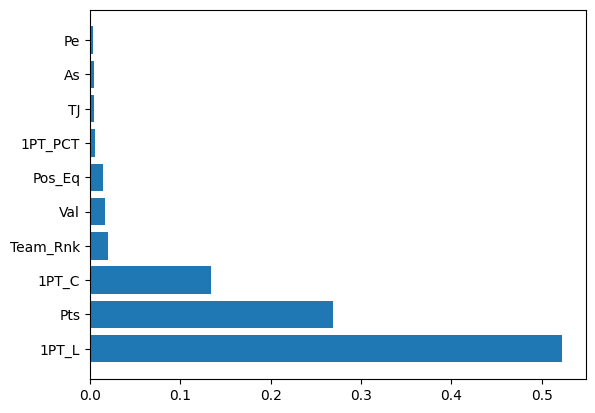

In [26]:
import numpy as np
sorted_idx = clf.feature_importances_.argsort()[::-1]
sorted_idx
axe=np.array(features)
from matplotlib import pyplot as plt
plt.barh(axe[sorted_idx][:10], clf.feature_importances_[sorted_idx][:10])